# 量子计数

为了理解这个算法，你首先需要理解 Grover 算法和量子相位估计算法。与 Grover 算法试图找到 Oracle 的解不同，量子计数算法告诉我们有多少这样的解。这个算法很有趣，因为它结合了量子搜索和量子相位估计。

## 1. 概述

### 1.1 直观理解

在量子计数中，我们只需使用量子相位估计算法来找到一个 Grover 搜索迭代的特征值。 Grover 算法的一次迭代 $G$ 在 $|\omega\rangle$， $|s'\rangle$ 基下将状态向量旋转 $\theta$：

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_5_0001.png" width="30%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

搜索空间中的解的百分比影响 $|s\rangle$ 和 $|s'\rangle$ 之间的差异。例如，如果没有很多解， $|s\rangle$ 会非常接近 $|s'\rangle$，而 $\theta$ 会非常小。事实证明，Grover 迭代器的特征值是 $e^{\pm i\theta}$，我们可以使用量子相位估计 (QPE) 来提取这个值，从而估计解的数量 ( $M$ )。

### 1.2 深入探讨

在 $|\omega\rangle$，$|s'\rangle$ 基下，我们可以将 Grover 迭代器写成矩阵形式：

$$
G =
\begin{pmatrix}
\cos{\theta} && -\sin{\theta} \\
\sin{\theta} && \cos{\theta}
\end{pmatrix}
$$

矩阵 $G$ 有特征向量：

$$
\begin{pmatrix}
-i \\
1
\end{pmatrix}
,
\begin{pmatrix}
i \\
1
\end{pmatrix}
$$

对应的特征值为 $e^{\pm i\theta}$。我们不需要将寄存器准备这两个状态中的任何一个，状态 $|s\rangle$ 位于 $|\omega\rangle$， $|s'\rangle$ 张成的空间中，是两个向量的叠加态。

$$
|s\rangle = \alpha |\omega\rangle + \beta|s'\rangle
$$

因此， QPE 算法的输出将是两个相位的叠加，当我们测量寄存器时，将获得这两个值中的一个。我们可以使用一些简单的数学运算来估计 $M$ 。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_5_0002.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

## 2. 代码实现

### 2.1 初始化代码

我们选择在线路的前 4 个量子比特上进行"计数"（我们将计数量子比特数称为 $t$ ，所以 $t = 4$ ），并在最后 4 个量子比特上进行"搜索"( $n = 4$ )。基于此，我们可以开始创建量子线路的构建块。

### 2.2 受控 Grover 迭代

Grover 算法中有一个我们知道有 5 个解 ( $M = 5$ ) 的 16 个态 ( $N = 2^n = 16$ ) 的 Oracle，与扩散算子结合使用:

In [19]:
import math

import matplotlib.pyplot as plt

import deepquantum as dq


def example_grover_iteration():
    """Small circuit with 5/16 solutions"""
    # Do circuit
    cir = dq.QubitCircuit(4)
    # Oracle
    cir.h(2)
    cir.h(3)
    cir.ccx(0, 1, 2)
    cir.h(2)
    cir.x(2)
    cir.ccx(0, 2, 3)
    cir.x(2)
    cir.h(3)
    cir.x(1)
    cir.x(3)
    cir.h(2)
    cir.x(2, [0, 1, 3])
    cir.x(1)
    cir.x(3)
    cir.h(2)
    # Diffuser
    cir.hlayer([0, 1, 2])
    cir.xlayer([0, 1, 2])
    cir.z(3)
    cir.x(3, [0, 1, 2])
    cir.xlayer([0, 1, 2])
    cir.hlayer([0, 1, 2])
    cir.z(3)
    return cir

我们可以使用 `.get_unitary()` 和 `.any` 从量子线路创建一个受控门。我们将 Grover 迭代器称为 `grit`：

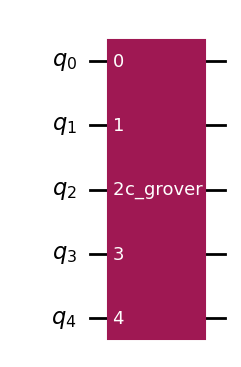

In [20]:
# Create controlled-Grover
grit = example_grover_iteration().get_unitary()
cir_test = dq.QubitCircuit(5)
cir_test.any(unitary=grit, wires=[1, 2, 3, 4], controls=0, name='_Grover')
cir_test.draw()

### 2.3 逆量子傅里叶变换

我们现在需要创建一个逆量子傅里叶变换。我们使用 t = 4 个量子比特创建这个门，因为这是我们在本案例中选择的计数量子比特数。

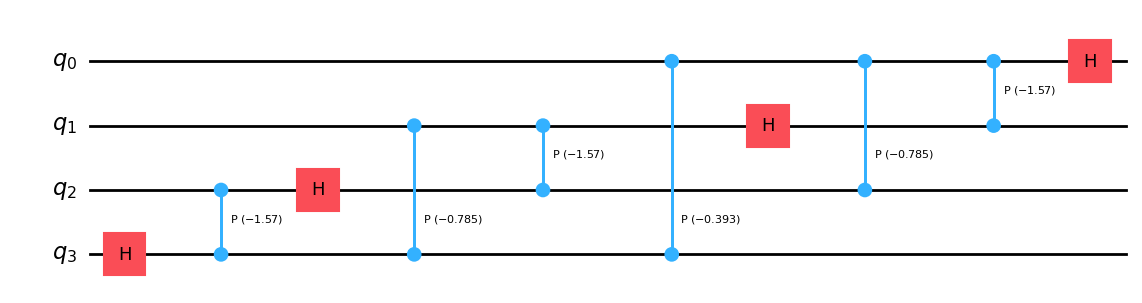

In [21]:
qft = dq.QuantumFourierTransform(nqubit=4, minmax=[0, 3], reverse=True).inverse()
qft.draw()

### 2.4 组合量子线路

我们现在已经拥有完成线路所需的一切！让我们把它组合在一起。

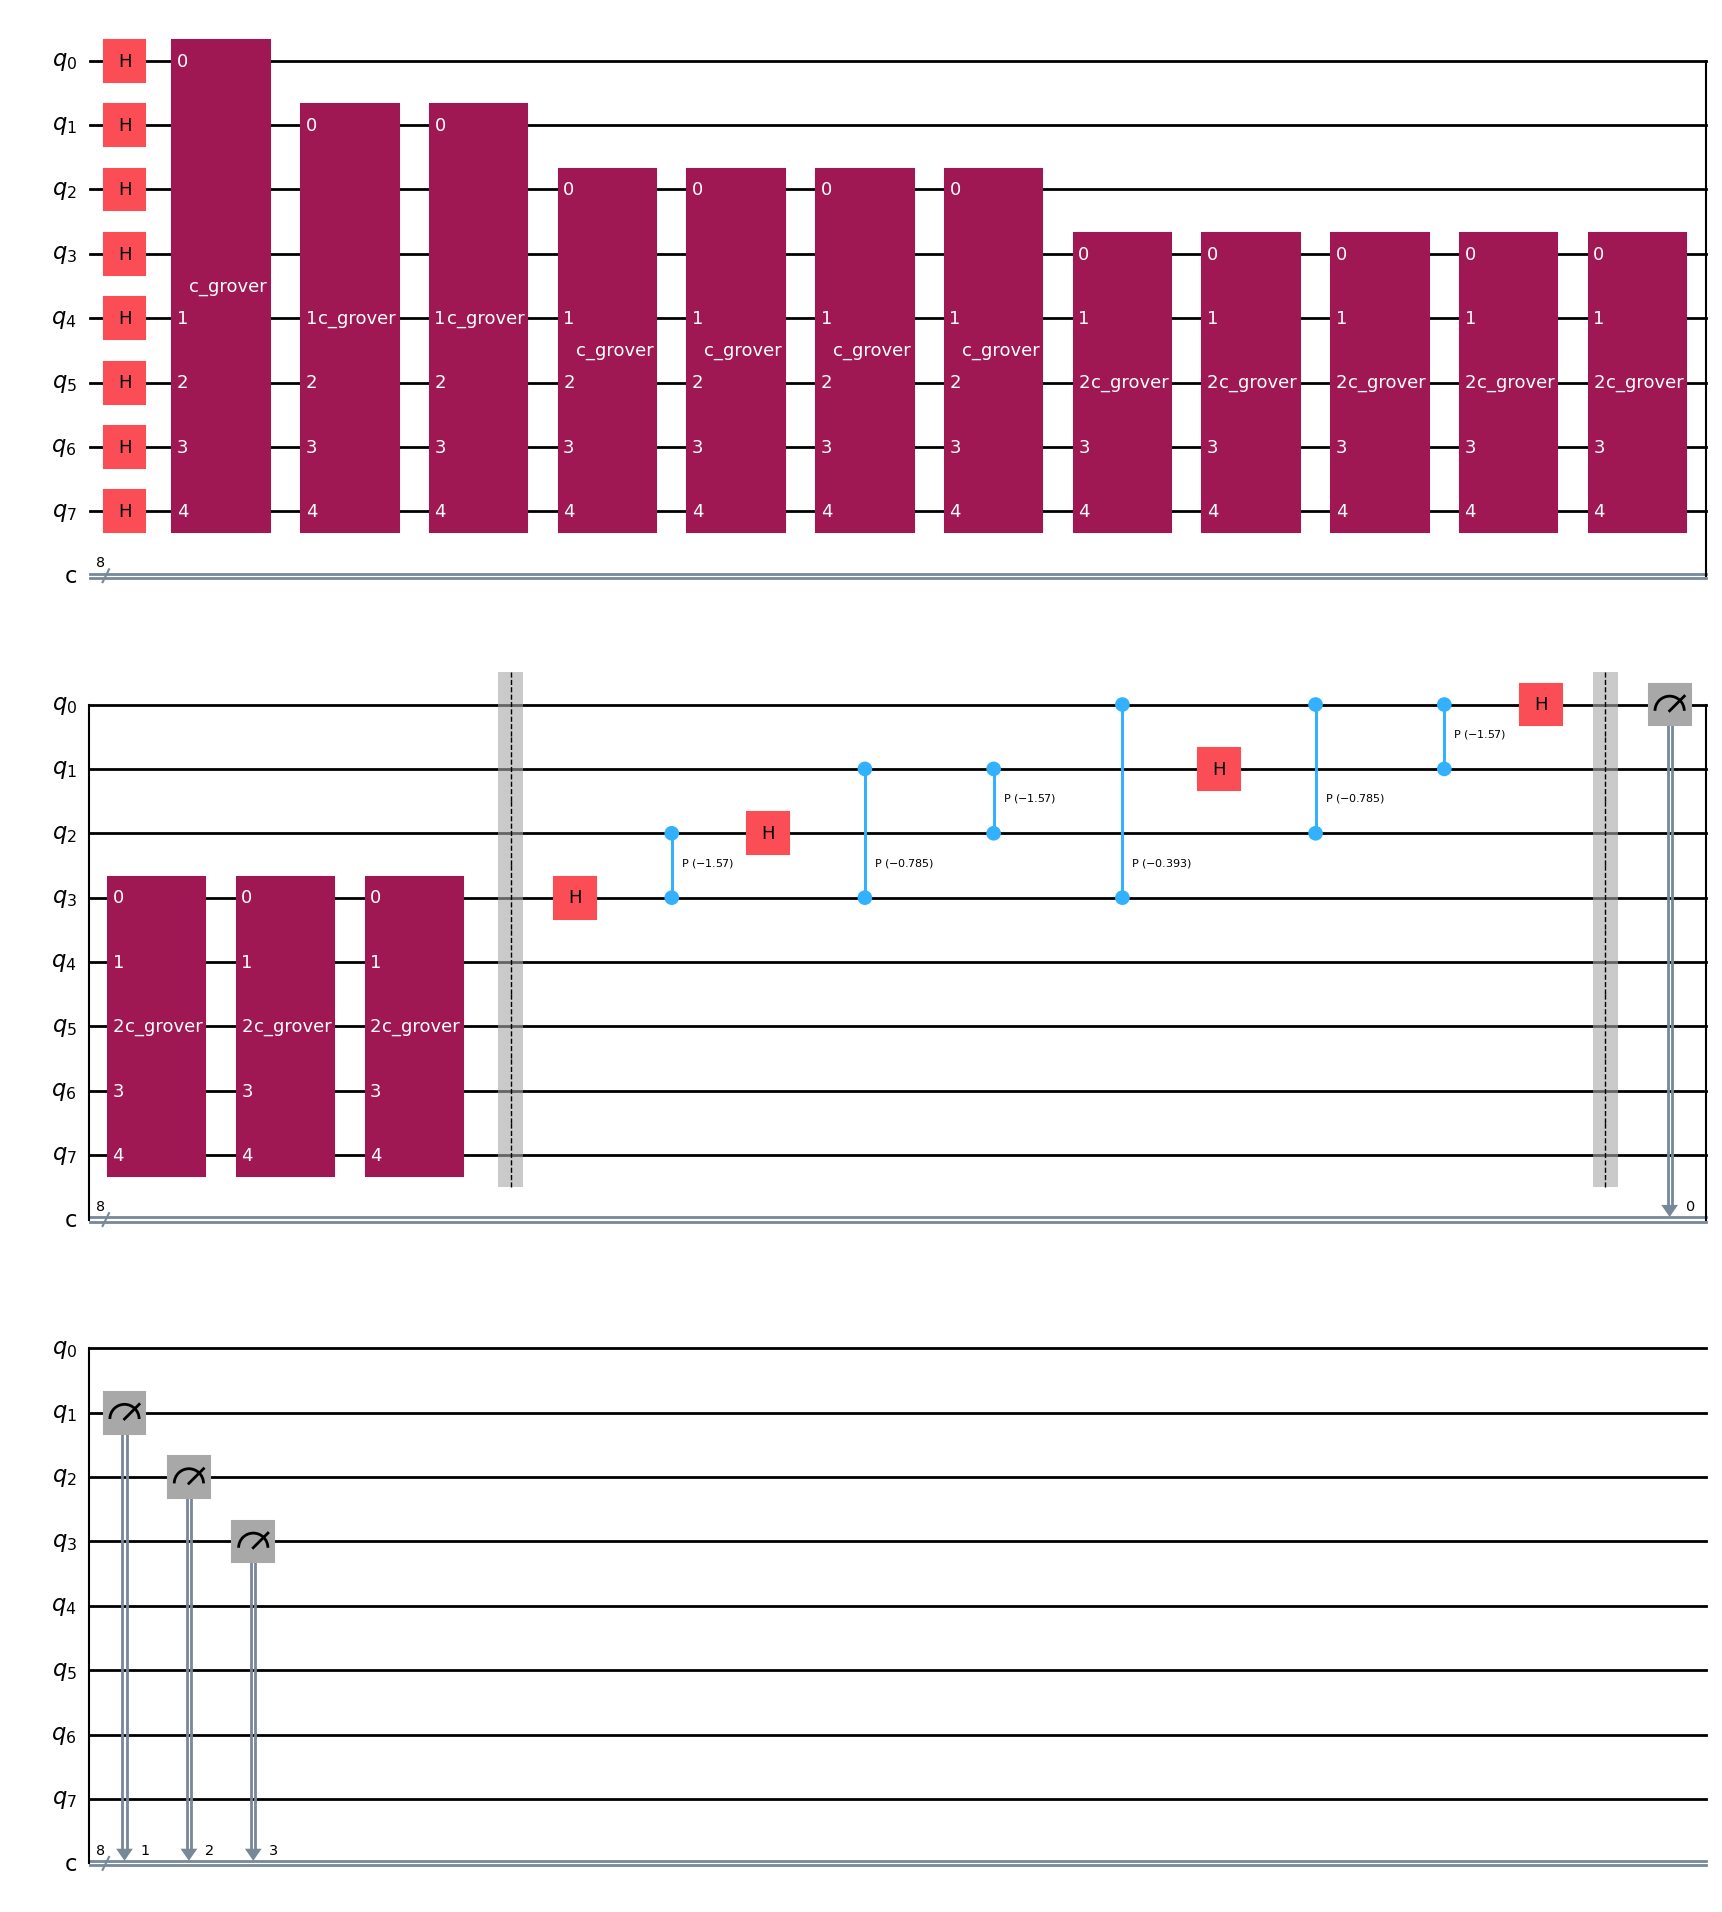

In [22]:
# 创建量子电路
t = 4  # 计数量子位的数量
n = 4  # 搜索量子位的数量
cir = dq.QubitCircuit(n + t)  # 一个包含 n+t 个量子位和 t 个经典位的电路

# 初始化所有量子位到 |+>
cir.hlayer()

# 开始受控Grover迭代
iterations = 1
for qubit in range(t):
    for _ in range(iterations):
        cir.any(unitary=grit, wires=list(range(t, n + t)), controls=qubit, name='_Grover')
    iterations *= 2

# 在计数量子位上执行逆量子傅里叶变换
cir.barrier()
cir.add(dq.QuantumFourierTransform(nqubit=n + t, minmax=[0, t - 1], reverse=True).inverse())

# 测量计数量子位
cir.barrier()
cir.measure(wires=list(range(t)))

# 显示电路图
cir.draw()

In [23]:
cir()

res = cir.measure(wires=list(range(t)))
print(res)

{'0101': 494, '1011': 530}


<BarContainer object of 2 artists>

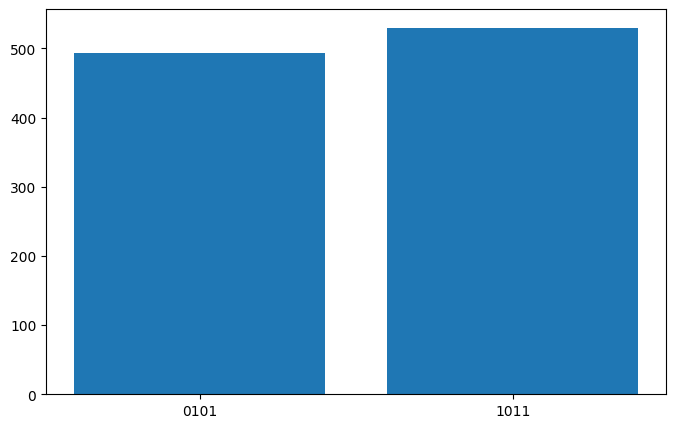

In [24]:
# 将数据分解为X和Y轴的值
labels = list(res.keys())
values = list(res.values())

# 创建条形图
plt.figure(figsize=(8, 5))  # 设置图形大小
plt.bar(labels, values)  # 绘制条形图

## 3. 仿真结果

我们可以看到有两个值特别突出，具有比其他值高得多的测量概率。这两个值对应于 $e^{i\theta}$ 和 $e^{-i\theta}$，但我们还看不到解的数量。我们需要再做一些处理才能得到这个信息。

我们将从输出数据中获取最可能结果的字符串，再将其存储为整数：

In [25]:
measured_str = max(res, key=res.get)
measured_int = int(measured_str, 2)
print(f'Register Output = {measured_int}')

Register Output = 11


## 4. 求解的数量 (M)

首先，我们要从 `measured_int` 中得到 $\theta$。你会记得 QPE 给我们一个测量值 $\text{value} = 2^n \phi$，来自特征值 $e^{2\pi i\phi}$，所以为了得到 $\theta$，我们需要：

$$
\theta = \text{value}\times\frac{2\pi}{2^t}
$$

我们可以从 $|s\rangle$ 和 $|s'\rangle$ 的内积中得到角度 $\theta/2$：

$$
\langle s'|s\rangle = \cos{\tfrac{\theta}{2}}
$$

并且 $|s\rangle$ (计算基态的均匀叠加) 可以用 $|\omega\rangle$ 和 $|s'\rangle$ 来表示：

$$
|s\rangle = \sqrt{\tfrac{M}{N}}|\omega\rangle + \sqrt{\tfrac{N-M}{N}}|s'\rangle
$$

$|s\rangle$ 和 $|s'\rangle$ 的内积是：

$$
\langle s'|s\rangle = \sqrt{\frac{N-M}{N}} = \cos{\tfrac{\theta}{2}}
$$

易知：

$$
N\sin^2{\frac{\theta}{2}} = M
$$

量子计数算法将告诉我们有多少状态不是解。我们简单地计算 $N-M$ 。

用代码表示:

In [26]:
theta = (measured_int / (2**t)) * math.pi * 2

N = 2**n
M = N * (math.sin(theta / 2) ** 2)
print(f'No. of Solutions = {N - M:.1f}')

No. of Solutions = 4.9


我们可以看到，我们得到了（近似）正确的答案，我们可以使用以下公式近似计算这个答案的误差[1]：

In [27]:
m = t - 1  # Upper bound: Will be less than this
err = (math.sqrt(2 * M * N) + N / (2 ** (m + 1))) * (2 ** (-m))
print(f'Error < {err:.2f}')

Error < 2.48


## 6. 参考文献

[1] Nielsen M A, Chuang I L. Quantum computation and quantum information[M]. Cambridge university press, 2010.